In [50]:
import duckdb as db 
import pandas as pd 
import pyarrow as py 
import matplotlib.pyplot as plt
import numpy as np

Flight log data spans from January 1, 2020 to November 30th, 2025.

In [27]:
UNCLEAN_PATH = "master_flights.parquet"

Define a flight being delayed as taking off more than 15 minutes after the sheduled time or landing more than 15 minutes after the expected time.

In [4]:
con = db.connect()

# Data Cleaning and Preprocessing

In [28]:
con.execute(f"""
    COPY (
        SELECT
            FlightDate,
            Year,
            Quarter,
            Month,
            DayofMonth,
            DayOfWeek,

            CRSDepTime,
            CRSArrTime,
            DepTimeBlk,
            ArrTimeBlk,

            Reporting_Airline,
            DOT_ID_Reporting_Airline,

            OriginAirportID,
            Origin,
            OriginCityName,
            OriginState,
            OriginStateName,

            DestAirportID,
            Dest,
            DestCityName,
            DestState,
            DestStateName,

            DepTime,
            DepDelay,
            DepDelayMinutes,
            DepDel15,
            DepartureDelayGroups,
            DepTimeBlk,

            ArrTime,
            ArrDelay,
            ArrDelayMinutes,
            ArrDel15,
            ArrivalDelayGroups,
            ArrTimeBlk,

            CRSElapsedTime,
            ActualElapsedTime,
            AirTime,
            Distance,
            DistanceGroup,
            TaxiOut,
            TaxiIn,

            CarrierDelay,
            WeatherDelay,
            NASDelay,
            SecurityDelay,
            LateAircraftDelay

            FROM read_parquet('{UNCLEAN_PATH}')
            WHERE Diverted = 0 AND Cancelled = 0
        )
        TO 'clean_flights.parquet'
        (FORMAT PARQUET);
 """)



In [29]:
PATH = "clean_flights.parquet"

In [30]:
total_flights = con.execute(f""" 
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    """).fetchone()[0]
print(total_flights)

36826021


In [32]:
total_delayed_flights = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE DepDelay > 15 OR ArrDelay > 15
    """).fetchone()[0]

print(total_delayed_flights)

8148991


So 8,148,991 flights were delayed in the datasets timeframe.

In [33]:
percent_flights_delayed = total_delayed_flights / total_flights

print(percent_flights_delayed)

0.2212835049434203


Roughly 22.1% of all flgihts were delayed in the datasets timefram.

In [34]:
flights_over_3_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 180
    """).fetchone()[0]

print(flights_over_3_hours)

5379847


In [35]:
delayed_flights_over_3_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 180 AND (DepDelay > 15 OR ArrDelay > 15)
    """).fetchone()[0]

print(delayed_flights_over_3_hours)

1357248


1,357,248 of all flights over 3 hours where delayed by 15 or more minutes.

In [36]:
percent_flights_delayed_over_3_hours = delayed_flights_over_3_hours / flights_over_3_hours

print(percent_flights_delayed_over_3_hours)

0.2522837545380008


And 25.2% of all flights over 3 hours where delayed by 15 or more minutes.

In [37]:
flights_over_5_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 300
    """).fetchone()[0]

delayed_flights_over_5_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 300 AND (DepDelay > 15 OR ArrDelay > 15)
    """).fetchone()[0]

print(delayed_flights_over_5_hours)

print(delayed_flights_over_5_hours/flights_over_5_hours)


256121
0.26077053870511213


256121 of flights over 5 hours were delayed which was 26.1% of flights over 5 hours.

## Exploritory Graphs

In [47]:
df = con.execute(f"""
    SELECT DepDelayMinutes
    FROM read_parquet('{PATH}')
    USING SAMPLE 1000000 ROWS""").df()

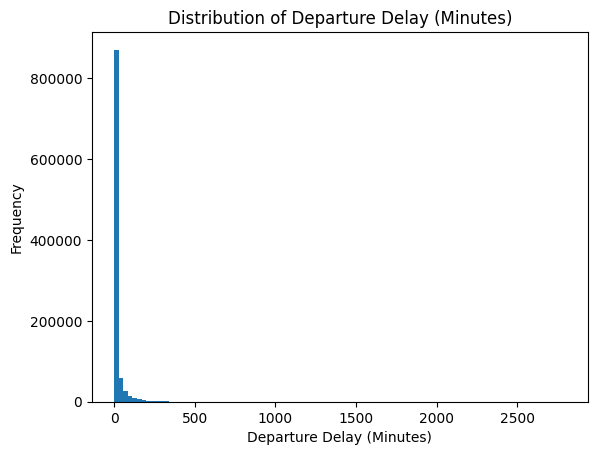

In [48]:
plt.hist(df["DepDelayMinutes"], bins = 100)
plt.title("Distribution of Departure Delay (Minutes)")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

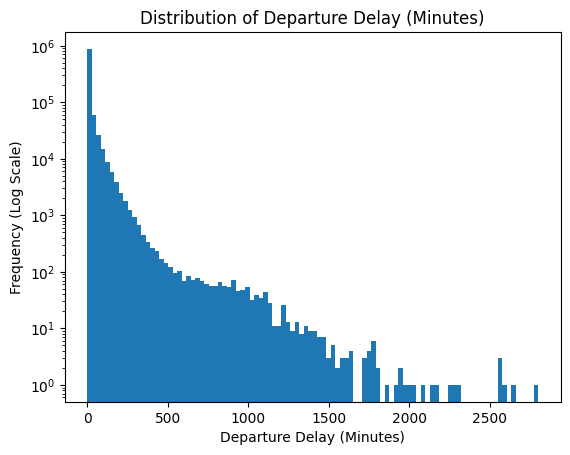

In [49]:
plt.hist(df["DepDelayMinutes"], bins = 100, log=True)
plt.title("Distribution of Departure Delay (Minutes)")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Frequency (Log Scale)")
plt.show()

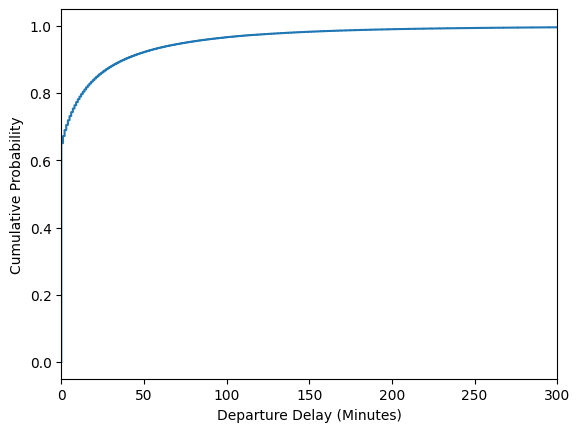

In [51]:
sorted_delays = np.sort(df["DepDelayMinutes"])
cdf = np.arange(len(sorted_delays)) / float(len(sorted_delays))

plt.plot(sorted_delays, cdf)
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Cumulative Probability")
plt.xlim(0, 300)
plt.show()

In [52]:
print(np.percentile(df["DepDelayMinutes"], [50, 75, 90, 95, 99]))

[  0.   7.  38.  75. 199.]


In [53]:
monthly_delay_rate = con.execute(f"""
    SELECT
        Year,
        Month,
        AVG(CASE 
            WHEN DepDelayMinutes > 15 OR ArrDelayMinutes > 15 THEN 1
            ELSE 0
        END) AS DelayRate
    FROM read_parquet('{PATH}')
    GROUP BY Year, Month
    ORDER BY Year, Month
""").df()

In [56]:
monthly_delay_rate["Date"] = pd.to_datetime(
    monthly_delay_rate["Year"].astype(str) + "-" + monthly_delay_rate["Month"].astype(str)
)

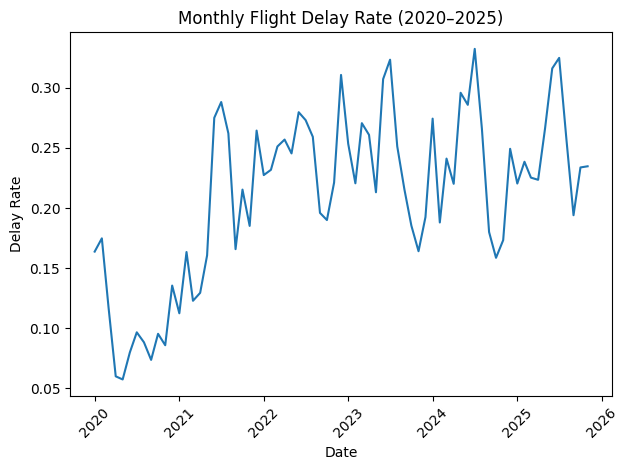

In [57]:
plt.plot(monthly_delay_rate["Date"], monthly_delay_rate["DelayRate"])
plt.title("Monthly Flight Delay Rate (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()